In [10]:
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from diffusers import DiTTransformer2DModel


In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = torchvision.datasets.CIFAR10(
    root='../data',
    train=True,
    download=True,
    transform=transform,
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
)

print(f'Dataset size: {len(dataset)}')
print(f'Image shape: {dataset[0][0].shape}')
print(dataset.classes)


Dataset size: 50000
Image shape: torch.Size([3, 32, 32])
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


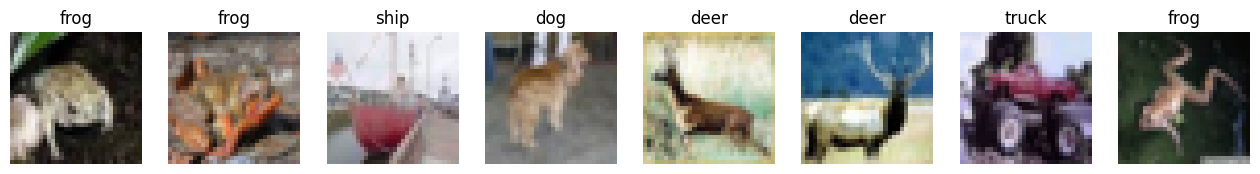

In [12]:
images, labels = next(iter(dataloader))
classes = dataset.classes

fig, axes = plt.subplots(1, 8, figsize=(16, 2))

for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0)
    img = (img + 1) / 2
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.show()


In [13]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(alphas_cumprod[0])
print(alphas_cumprod[-1])


device: mps
tensor(0.9999, device='mps:0')
tensor(4.0358e-05, device='mps:0')


In [14]:
def add_noise(x_0, t):
    noise = torch.randn_like(x_0)
    sqrt_alpha_bar = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)
    x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
    return x_t, noise


## DiT backbone from diffusers

Everything above is copied from DDPM because the diffusion process stays the same.
The only thing that changes is the denoising backbone: U-Net -> DiT.

For now this uses `diffusers.DiTTransformer2DModel` as a library backbone.
This DiT is class-conditional, so we pass CIFAR-10 labels as `class_labels`.
Later, when we build DiT from scratch, this conditioning path is what we will replace with GNN spatial embeddings.


In [19]:
model = DiTTransformer2DModel(
    sample_size=32,
    patch_size=4,
    in_channels=3,
    out_channels=3,
    num_layers=8,
    num_attention_heads=6,
    
    attention_head_dim=64,
    num_embeds_ada_norm=10,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'DiT params: {n_params / 1e6:.1f}M')


DiT params: 23.6M


In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 5

model.train()
for epoch in range(epochs):
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        t = torch.randint(0, T, (images.shape[0],), device=device)
        x_t, noise = add_noise(images, t)
        predicted_noise = model(x_t, timestep=t, class_labels=labels).sample
        loss = F.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch} | Loss: {loss.item():.4f}')


Epoch 0 | Loss: 0.0754
Epoch 1 | Loss: 0.0596
Epoch 2 | Loss: 0.0479
Epoch 3 | Loss: 0.0358
Epoch 4 | Loss: 0.0372


In [21]:
@torch.no_grad()
def sample(model, class_labels, n_images=None):
    model.eval()

    if n_images is None:
        n_images = len(class_labels)
    class_labels = torch.as_tensor(class_labels, device=device, dtype=torch.long)

    x = torch.randn(n_images, 3, 32, 32, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((n_images,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, timestep=t_batch, class_labels=class_labels).sample

        alpha_t = alphas[t]
        alpha_bar_t = alphas_cumprod[t]
        beta_t = betas[t]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x - coef * predicted_noise)

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = mean + torch.sqrt(beta_t) * z

    return x


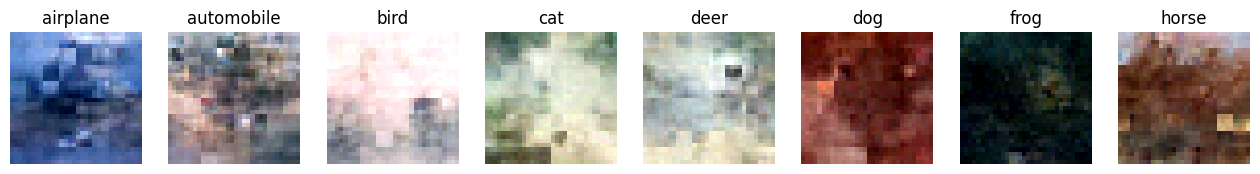

In [22]:
sample_labels = torch.arange(8, device=device) % 10
generated = sample(model, class_labels=sample_labels)
generated = (generated.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = generated[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.set_title(dataset.classes[int(sample_labels[i])])
    ax.axis('off')
plt.show()
